## Imports, Style, and Reproducibility
- Load trained models
- Define spatial grid
- Set plotting utilities

In [4]:
# %load_ext is safe to repeatedly run in a Jupyter notebook; it will just ignore duplicates.
#%reload_ext autoreload
#%autoreload 2
%matplotlib inline

In [5]:
import os
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "DejaVu Sans"   # works on all OSes
import seaborn as sns

# Figures
#sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
})

# Repo imports (assumes repo root is on PYTHONPATH)
from model import InverseSchrodingerModel
from utils import make_grid, set_global_seed
from physics import tise_loss, potential_smoothness_loss, wavefunction_normalization_loss
from inverse import data_mismatch_loss
from pod import pod_decomposition

set_global_seed(27)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1 - Training the Model

### 1️⃣ Synthetic problem definition
Create a 1-D harmonic oscillator test case for the inverse Schrödinger model to try and recover.

In [6]:
# Spatial grid
n_points = 256        # Number of collocation points
x = make_grid(-5.0, 5.0, n_points)       # (n_points, 1) -> n_points collocation points
dx = float(x[1] - x[0])                  # grid spacing (scalar)

# Choose a known analytic potential (e.g., harmonic oscillator)
V_true = 0.5 * x.squeeze()**2       # shape (N,)

# Analytic eigenfunctions (Hermite-Gaussians) for the chosen analytic potential (harmonic oscillator)
def hermite_gauss(n: int, x_vals: torch.Tensor) -> torch.Tensor:
    """Return the nth normalized harmonic oscillator eigenfunction."""
    from math import factorial, sqrt, pi
    import scipy.special as sp
    norm = 1.0 / sqrt(2.0**n * factorial(n)) * (pi**-0.25)
    # sp.hermite returns a callable polynomial; evaluate on x_vals
    return norm * sp.hermite(n)(x_vals) * torch.exp(-0.5 * x_vals**2)

n_states = 3     # number of eigenstates to evaluate/learn
psi_true = [hermite_gauss(n, x.squeeze()) for n in range(n_states)]
E_true = torch.tensor([0.5, 1.5, 2.5])  # exact energies (hbar = omega = 1)

# Synthetic observed data with some noise so the model has something to fit
rho_obs = [psi**2 + 0.02 * torch.randn_like(psi) for psi in psi_true]
E_obs = E_true + 0.05 * torch.randn_like(E_true)

### 2️⃣ Training loop
Train the inverse Schrödinger model on synthetic observed data (defined above). 

In [7]:
# ============================================================================
# 🎛️ CONFIGURATION PARAMETERS
# ============================================================================
# Training hyperparameters
lr              = 5e-3      # Learning rate
epochs          = 6_000     # Number of training epochs
log_every       = 800       # Print loss every N epochs

# Build the network
model = InverseSchrodingerModel(
    n_states=n_states,
    hidden_dims=[64, 64],
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

lambdas = {"data": 1.0, "physics": 1.0, "smooth": 1e-2, "norm": 25}

# ----------------------------------------------------------------------
# Training loop (with component logging)
# ----------------------------------------------------------------------

loss_history = []
physics_history = []    # TISE  residual
data_history = []       # data-fit
smooth_history = []     # potential smoothness
norm_history = []       # normalized wavefunction penalty

for epoch in range(1, epochs + 1):
    # Run a single optimization step and retrieve the three components
    optimizer.zero_grad()

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Physics‑informed loss -------------------
    loss_physics = tise_loss(
        model.psi_theta(x),     # list[psi_n(theta, x)]
        model.V_theta(x),       # V(theta, x)
        model.E_theta(),        # E(theta)
        dx,
    )

    # ------------------- Smoothness regularizer -------------------
    loss_smooth = potential_smoothness_loss(model.V_theta(x), dx)

    # ------------------- Data‑fit loss ----------------------------
    loss_data = data_mismatch_loss(
        model.psi_theta(x),     # learned psi_n(theta, x)
        model.E_theta(),        # learned energies
        rho_obs,                # observed probability densities
        E_obs,                  # observed energies
    )

    # ------------------- Normalization penalty -------------------
    loss_norm = wavefunction_normalization_loss(
        model.psi_theta(x),
        dx
    )

    # ------------------- Weighted sum ----------------------------
    total_loss = (
        lambdas["data"] * loss_data
        + lambdas["physics"] * loss_physics
        + lambdas["smooth"] * loss_smooth
        + lambdas["data"] * loss_norm
    )

    total_loss.backward()
    optimizer.step()

    # ------------------- Store scalars ---------------------------
    loss_history.append(total_loss.item())
    physics_history.append(loss_physics.item())
    data_history.append(loss_data.item())
    smooth_history.append(loss_smooth.item())
    norm_history.append(loss_norm.item())

    # ----- logging -----------------------------------------------
    if epoch % log_every == 0 or epoch == 1:
        print(f" epoch {epoch:4d} | total={total_loss.item():.6e} "
              f" | phys={loss_physics.item():.6e} "
              f" | data={loss_data.item():.6e} "
              f" | smooth={loss_smooth.item():.6e}"
              f" | norm={loss_norm.item():.6e}")

# ----------------------------------------------------------------------
# Post-training sanity check
# ----------------------------------------------------------------------
initial_loss = loss_history[0]
final_loss = loss_history[-1]
print("\n ✔️ Training complete!")
print(f"Initial loss: {initial_loss:.6e}")
print(f"Final loss: {final_loss:.6e}")

 epoch    1 | total=7.779355e+00  | phys=5.803761e-02  | data=7.380219e+00  | smooth=3.279174e-01 | norm=3.378191e-01
 epoch  800 | total=4.040592e-01  | phys=3.742162e-02  | data=3.634424e-01  | smooth=9.115605e-03 | norm=3.103931e-03
 epoch 1600 | total=8.842218e-02  | phys=2.954643e-02  | data=5.238474e-02  | smooth=7.518705e-03 | norm=6.415825e-03
 epoch 2400 | total=5.367173e-02  | phys=1.113126e-02  | data=4.159129e-02  | smooth=1.325949e-02 | norm=8.165835e-04
 epoch 3200 | total=4.265216e-02  | phys=9.478029e-03  | data=3.257060e-02  | smooth=1.839908e-02 | norm=4.195384e-04
 epoch 4000 | total=3.824413e-02  | phys=8.439098e-03  | data=2.919429e-02  | smooth=2.427099e-02 | norm=3.680360e-04
 epoch 4800 | total=3.497101e-02  | phys=8.137808e-03  | data=2.638062e-02  | smooth=2.063303e-02 | norm=2.462487e-04
 epoch 5600 | total=3.284509e-02  | phys=8.295015e-03  | data=2.416359e-02  | smooth=1.965063e-02 | norm=1.899798e-04

 ✔️ Training complete!
Initial loss: 7.779355e+00
Final

## Part 2 - Figures

## 1️⃣ Figure 1: Training curve
### 📈 Plot
- Figure 1a: Total loss vs. epoch
- Figure 1b: Physics loss vs epoch
- Figure 1c: Data loss vs. epoch
- Figure 1d: Smoothness loss vs. epoch

🗃️ Figure saved to ../artifacts/demo_visuals/training_curves.png


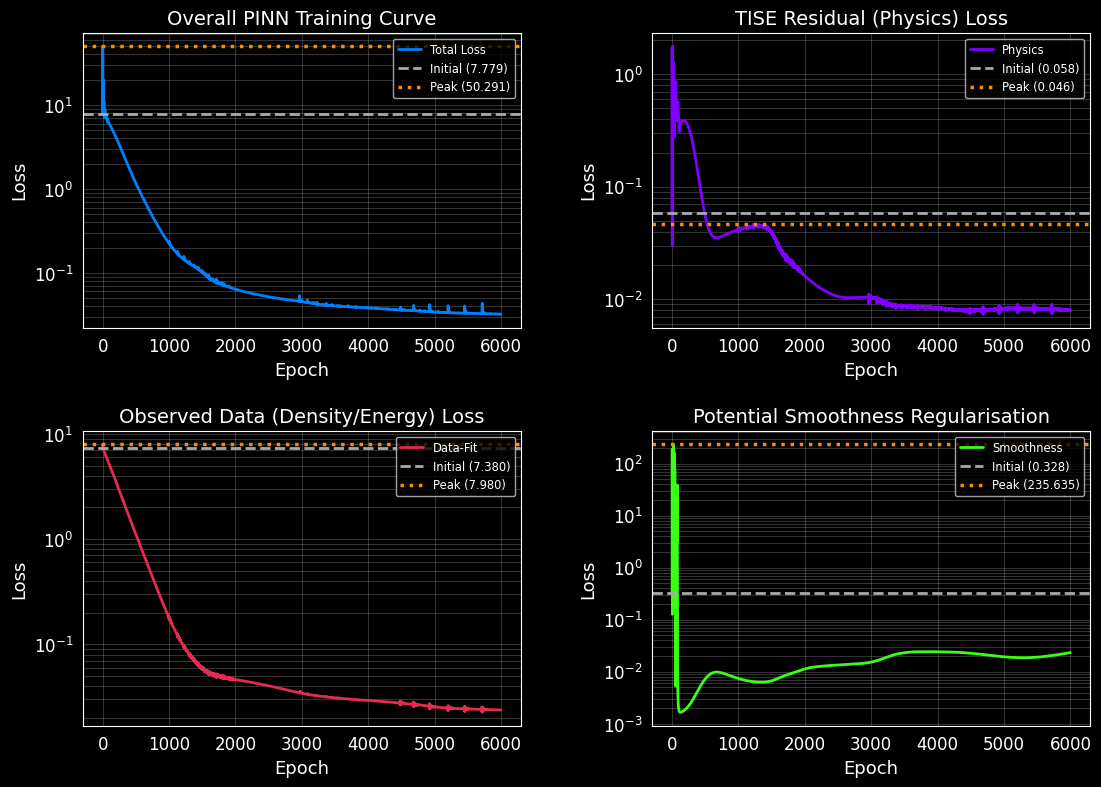

In [8]:
# --------------------------------------------------------------
# 1️⃣  Ensure histories have the right names
# --------------------------------------------------------------
assert len(loss_history) == len(physics_history) == len(data_history) == len(smooth_history)

# --------------------------------------------------------------
# 2️⃣  Compute initial / peak values safely
# --------------------------------------------------------------
import torch, os

peak_total_val   = torch.max(torch.tensor(loss_history)).item()
initial_total    = loss_history[0]

peak_phys_val    = max(physics_history[1000:] or physics_history)
initial_phys_val = physics_history[0]

peak_data_val    = max(data_history)
initial_data_val = data_history[0]

peak_smooth_val  = max(smooth_history)
initial_smooth_val = smooth_history[0]

# --------------------------------------------------------------
# 3️⃣  Build the figure (total loss spans full top row)
# --------------------------------------------------------------
fig = plt.figure(figsize=(13, 9))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.30)

# ----- Total loss (spans both columns) -----
ax_total = fig.add_subplot(gs[0, 0])
ax_total.plot(loss_history, linewidth=2, color="#007FFF", label="Total Loss")
ax_total.axhline(initial_total, color="#A9A9A9", ls="--", lw=2,
                 label=f"Initial ({initial_total:.3f})")
ax_total.axhline(peak_total_val, color="#FF8C00", ls=":", lw=2.5,
                 label=f"Peak ({peak_total_val:.3f})")
ax_total.set_yscale("log")
ax_total.set_xlabel("Epoch")
ax_total.set_ylabel("Loss")
ax_total.set_title("Overall PINN Training Curve")
ax_total.grid(True, which="both", alpha=0.2)
ax_total.legend(frameon=True, fontsize="x-small", loc="upper right")

# ----- Physics loss -----
ax_phys = fig.add_subplot(gs[0, 1])
ax_phys.plot(physics_history, color="#8000FF", linewidth=2, label="Physics")
ax_phys.axhline(initial_phys_val, color="#A9A9A9", ls="--", lw=2,
                label=f"Initial ({initial_phys_val:.3f})")
ax_phys.axhline(peak_phys_val, color="#FF8C00", ls=":", lw=2.5,
                label=f"Peak ({peak_phys_val:.3f})")
ax_phys.set_yscale("log")
ax_phys.set_xlabel("Epoch")
ax_phys.set_ylabel("Loss")
ax_phys.set_title("TISE Residual (Physics) Loss")
ax_phys.grid(True, which="both", alpha=0.2)
ax_phys.legend(frameon=True, fontsize="x-small", loc="upper right")

# ----- Data‑fit loss -----
ax_data = fig.add_subplot(gs[1, 0])
ax_data.plot(data_history, color="#E52B50", linewidth=2, label="Data‑Fit")
ax_data.axhline(initial_data_val, color="#A9A9A9", ls="--", lw=2,
                label=f"Initial ({initial_data_val:.3f})")
ax_data.axhline(peak_data_val, color="#FF8C00", ls=":", lw=2.5,
                label=f"Peak ({peak_data_val:.3f})")
ax_data.set_yscale("log")
ax_data.set_xlabel("Epoch")
ax_data.set_ylabel("Loss")
ax_data.set_title("Observed Data (Density/Energy) Loss")
ax_data.grid(True, which="both", alpha=0.2)
ax_data.legend(frameon=True, fontsize="x-small", loc="upper right")

# ----- Smoothness loss -----
import numpy as np
from scipy.signal import savgol_filter

# Convert list → np array
smooth_arr = np.array(smooth_history)

# Savitzky‑Golay (window length must be odd, polyorder ≤ window‑1)
smooth_arr_filt = savgol_filter(smooth_arr, window_length=31, polyorder=3)

ax_smooth = fig.add_subplot(gs[1, 1])
# Plot `smooth_arr_filt` instead of `smooth_history`
#ax_smooth.plot(smooth_arr_filt, color="#39FF14", linewidth=2,
#              label="Smoothness (filtered)")
ax_smooth.plot(smooth_history, color="#39FF14", linewidth=2, label="Smoothness")
ax_smooth.axhline(initial_smooth_val, color="#A9A9A9", ls="--", lw=2,
                  label=f"Initial ({initial_smooth_val:.3f})")
ax_smooth.axhline(peak_smooth_val, color="#FF8C00", ls=":", lw=2.5,
                  label=f"Peak ({peak_smooth_val:.3f})")
ax_smooth.set_yscale("log")
ax_smooth.set_xlabel("Epoch")
ax_smooth.set_ylabel("Loss")
ax_smooth.set_title("Potential Smoothness Regularisation")
ax_smooth.grid(True, which="both", alpha=0.2)
ax_smooth.legend(frameon=True, fontsize="x-small", loc="upper right")

# --------------------------------------------------------------
# 4️⃣  Save (ensure folder exists) and show
# --------------------------------------------------------------
out_path = "../artifacts/demo_visuals/training_curves.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"🗃️ Figure saved to {out_path}")

if plt.get_backend() != "agg":
    plt.show()

## 2️⃣ Figure 2: Learned potential vs. Ground truth potential

### 📈 Plot
- $V_\theta(x)$ vs. $x$
- Ground truth $V(x)$

### 💬 Messages
- Smoothness prior effect
- Identifiability limits
- Bias vs. variance tradeoff

### ✖️ Failure modes
- Flattening
- Over-smoothing
- Boundary artifacts

🗃️ Potential figure saved to ../artifacts/demo_visuals/learned_potential.png


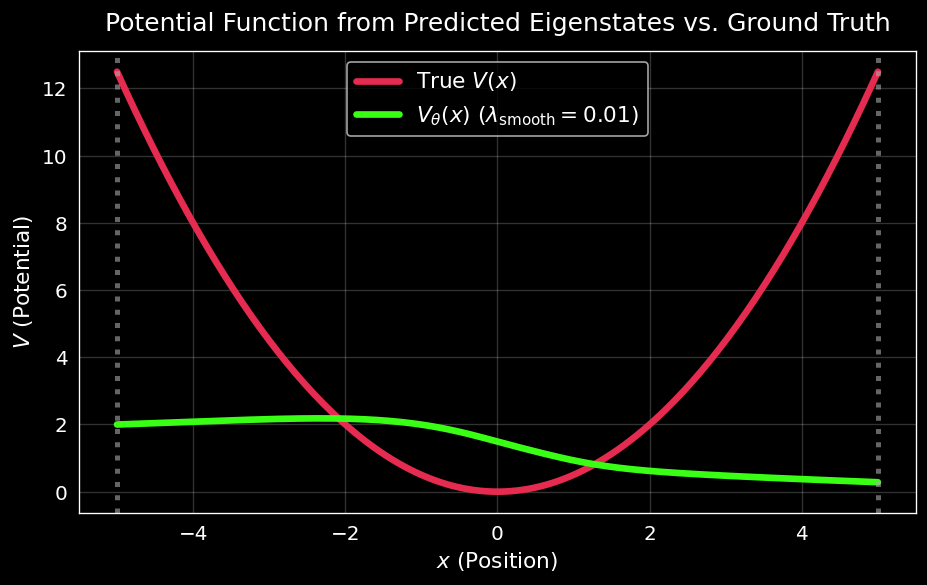

In [9]:
# ------------------------------------------------------------------
# 0️⃣ Figure Settings
# ------------------------------------------------------------------
#sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120    # sharper on most screens

true_color = "#E52B50"
learned_color = "#39FF14"
boundary_color = "#A9A9A9"

# ------------------------------------------------------------------
# 1️⃣  Pull the tensors out of the model (no gradients)
# ------------------------------------------------------------------
model.eval()    # safety: no dropout/B-N
with torch.no_grad():
    V_learned = model.V_theta(x).squeeze()      # shape (N,)
    if isinstance(V_true, torch.Tensor):
        V_true_tensor = V_true.squeeze()   # remove any singleton dimensions
    else:
        V_true_tensor = torch.tensor(V_true)

# ------------------------------------------------------------------
# 2️⃣  Plot
# ------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(
    x.squeeze(),
    V_true_tensor,
    label=r"True $V(x)$",
    color=true_color,
    linewidth=4,
)

plt.plot(
    x.squeeze(),
    V_learned,
    label=rf"$V_{{\theta}}(x)$ ($\lambda_{{\text{{smooth}}}}={lambdas['smooth']}$)",
    color=learned_color,
    linewidth=4,
)

# ------------------------------------------------------------------
# 3️⃣  Optional: highlight boundary artifacts (if you suspect them)
# ------------------------------------------------------------------
# Example: draw a faint vertical line at the domain edges
plt.axvline(x.min(), color=boundary_color, lw=3, ls=":", alpha=0.6)
plt.axvline(x.max(), color=boundary_color, lw=3, ls=":", alpha=0.6)

# ------------------------------------------------------------------
# 4️⃣  Axis cosmetics & annotations
# ------------------------------------------------------------------
plt.xlabel(r"$x$ (Position)", fontsize=13)
plt.ylabel(r"$V$ (Potential)", fontsize=13)
plt.title("Potential Function from Predicted Eigenstates vs. Ground Truth", fontsize=15, pad=12)

plt.legend(frameon=True, fontsize="13", loc="best")
plt.grid(True, which="both", alpha=0.2)

# ------------------------------------------------------------------
# 5️⃣  Save & show
# ------------------------------------------------------------------
out_path = "../artifacts/demo_visuals/learned_potential.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"🗃️ Potential figure saved to {out_path}")

plt.show()

## 3️⃣ Figure 3: Learned wave function $\psi_n^\theta(x)$
### 📈 Plot
- Learned $\psi_0^\theta$, $\psi_1^\theta$ and $\psi_2^\theta$ vs. Ground Truth $\psi_0$, $\psi_1$ and $\psi_2$  (3 subplots)

### 💬 Messages
- Phase ambiguity
- Shape consistency
- Node Structure

> ✨ Do _not_ claim correctness; just structure.

🗃️ Wavefunction figure saved to ../artifacts/demo_visuals/learned_wavefunctions.png


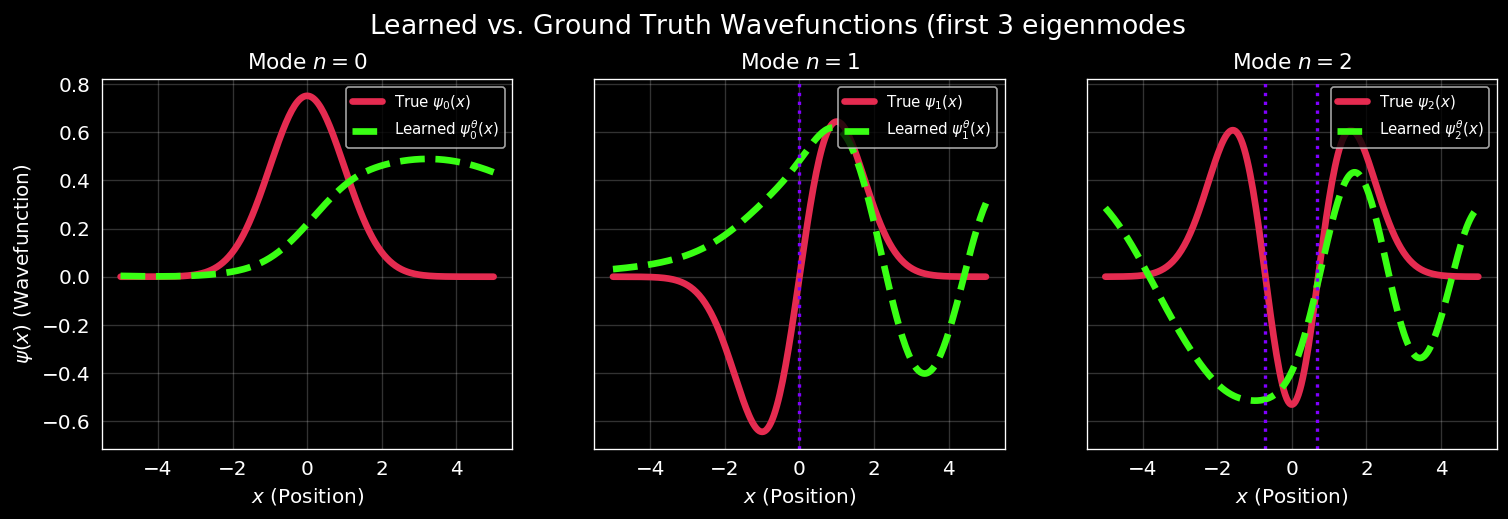

In [10]:
# ------------------------------------------------------------------
# 0️⃣ Figure Settings
# ------------------------------------------------------------------
#sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120    # sharper on most screens

# ------------------------------------------------------------------
# 1️⃣ Pull tensors from the model (no grads)
# ------------------------------------------------------------------
model.eval()
with torch.no_grad():
    # Learned eigenfunctions - list of tensors, each shape (N,)
    psi_learned = [p.squeeze() for p in model.psi_theta(x)]

    # Ground truth eigenfunctions from the synthetic data generation code block
    # psi_true is a list of `n_states` tensors, each shape (N,)
    # Ensure all psi_true are 1-D for Matplotlib
    psi_true = [p.squeeze().float() for p in psi_true]

# ------------------------------------------------------------------
# 2️⃣ Align the *sign* (phase) of each learned mode
# ------------------------------------------------------------------
# Quantum wavefunctions are defined up to a global sign. If the learned eigenmode is flipped, the plot will look like a mirror image -> we flip it whenever the dot product with the true wavefunction is negative.
aligned_psi = []
for true, learned in zip(psi_true, psi_learned):
    # Compute inner product (discrete L2 overlap)
    overlap = torch.dot(true, learned)
    if overlap < 0:     # opposite sign -> flip
        aligned_psi.append(-learned)
    else:
        aligned_psi.append(learned)

# ------------------------------------------------------------------
# 3️⃣ Convert everything to NumPy (Matplotlib works with NumPy/CUDA‑free)
# ------------------------------------------------------------------
x_np = x.squeeze().cpu().numpy()
true_np = [p.cpu().numpy() for p in psi_true]
learned_np = [p.cpu().numpy() for p in aligned_psi]

# ------------------------------------------------------------------
# 4️⃣ Plot – three subplots, one per eigenmode
# ------------------------------------------------------------------
n_modes = n_states
fig, axes = plt.subplots(1, n_modes, figsize=(15, 4), sharey=True)

# Colors
true_color = "#E52B50"
learned_color = "#39FF14"
node_color = "#8000FF"

for idx, ax in enumerate(axes):
    # Ground truth
    ax.plot(
        x_np,
        true_np[idx],
        label=rf"True $\psi_{idx}(x)$",
        color=true_color,
        linewidth=4,
    )
    # Learned
    ax.plot(
        x_np,
        learned_np[idx],
        label=rf"Learned $\psi_{idx}^\theta(x)$",
        color=learned_color,
        linestyle="--",
        linewidth=4,
    )

    ax.set_xlabel(r"$x$ (Position)", fontsize=12)
    ax.set_title(rf"Mode $n={idx}$", fontsize=13)

    # Show nodes (zero-intersections) as vertical dotted lines
    # Detect sign changes in the *true* wavefunction to illustrate node locations
    true_vals = true_np[idx]
    sign_changes = (true_vals[:-1] * true_vals[1:] < 0).nonzero()[0]
    for sc in sign_changes:
        ax.axvline(x_np[sc], color=node_color, ls=":", lw=2)

    ax.grid(True, which="both", alpha=0.2)

# Shared y-label only on the leftmost axis
axes[0].set_ylabel(r"$\psi(x)$ (Wavefunction)", fontsize=12)

# Legend - one per subplot (Matplotlib will merge identical labels)
for ax in axes:
    ax.legend(fontsize=9, frameon=True, loc="upper right")

fig.suptitle(
    rf"Learned vs. Ground Truth Wavefunctions (first ${n_modes}$ eigenmodes)",
    fontsize=16,
    y=1.02,
)

# ------------------------------------------------------------------
# 6️⃣ Save & show
# ------------------------------------------------------------------
out_path = "../artifacts/demo_visuals/learned_wavefunctions.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"🗃️ Wavefunction figure saved to {out_path}")

plt.show()

### Diagnostics

In [11]:
# --------------------------------------------------------------
# 1️⃣  Verify data flow & basic statistics (you already did this)
# --------------------------------------------------------------
print("x shape:", x.shape)                     # (N, 1)
print("V_true min / max:", V_true.min().item(), V_true.max().item())
print("psi_true means :", [p.mean().item() for p in psi_true])
print("psi_learned means :", [p.mean().item() for p in psi_learned])

# --------------------------------------------------------------
# 2️⃣  Re‑compute the loss components for the *current* forward pass
# --------------------------------------------------------------
model.train()                     # put the model in training mode (drops dropout, etc.)

V_pred      = model.V_theta(x)                # (N, 1)
psi_pred    = model.psi_theta(x)              # list of (N, 1) tensors
E_pred      = model.E_theta()                 # (n_states,)

# ------------------------------------------------------------------
# 3️⃣  Compute each loss term (same formulas you use in train_step)
# ------------------------------------------------------------------
# Physics (TISE) loss
L_physics = tise_loss(psi_pred, V_pred, E_pred, dx)

# Smoothness regulariser on the potential
L_smooth = potential_smoothness_loss(V_pred, dx)

# Data‑fit loss (density + energy)
L_data = data_mismatch_loss(psi_pred, E_pred, rho_obs, E_obs)

# Weighted total loss – use the same λ’s you defined earlier
total_loss = (
    lambdas["data"]    * L_data
    + lambdas["physics"] * L_physics
    + lambdas["smooth"]  * L_smooth
)

print("\n--- Loss breakdown (current forward pass) ---")
print(f"Physics loss   : {L_physics.item():.6e}")
print(f"Smoothness loss: {L_smooth.item():.6e}")
print(f"Data loss      : {L_data.item():.6e}")
print(f"TOTAL loss     : {total_loss.item():.6e}")

# --------------------------------------------------------------
# 4️⃣  Back‑propagate to get gradients
# --------------------------------------------------------------
model.zero_grad()                # clears any stale grads
total_loss.backward()           # now gradients are populated

# --------------------------------------------------------------
# 5️⃣  Report mean absolute gradient magnitude per parameter
# --------------------------------------------------------------
print("\n--- Gradient magnitudes (mean absolute) ---")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_mean = param.grad.abs().mean().item()
        print(f"{name:30s}  {grad_mean:.3e}")
    else:
        print(f"{name:30s}  No grad")

x shape: torch.Size([256, 1])
V_true min / max: 0.00019223030540160835 12.5
psi_true means : [0.18754372000694275, 6.292069087976415e-10, 0.13260981440544128]
psi_learned means : [-0.2352859526872635, -0.15060493350028992, -0.11080092936754227]

--- Loss breakdown (current forward pass) ---
Physics loss   : 7.966471e-03
Smoothness loss: 2.341460e-02
Data loss      : 2.379727e-02
TOTAL loss     : 3.199789e-02

--- Gradient magnitudes (mean absolute) ---
energies                        6.591e-05
potential_net.net.0.weight      1.126e-04
potential_net.net.0.bias        4.060e-05
potential_net.net.2.weight      2.416e-05
potential_net.net.2.bias        4.160e-05
potential_net.net.4.weight      4.091e-04
potential_net.net.4.bias        6.238e-04
psi_nets.0.net.0.weight         1.769e-03
psi_nets.0.net.0.bias           8.023e-04
psi_nets.0.net.2.weight         1.022e-03
psi_nets.0.net.2.bias           1.809e-03
psi_nets.0.net.4.weight         2.561e-02
psi_nets.0.net.4.bias           6.547e-

## 4️⃣ Figure 4: Energy spectrum comparison

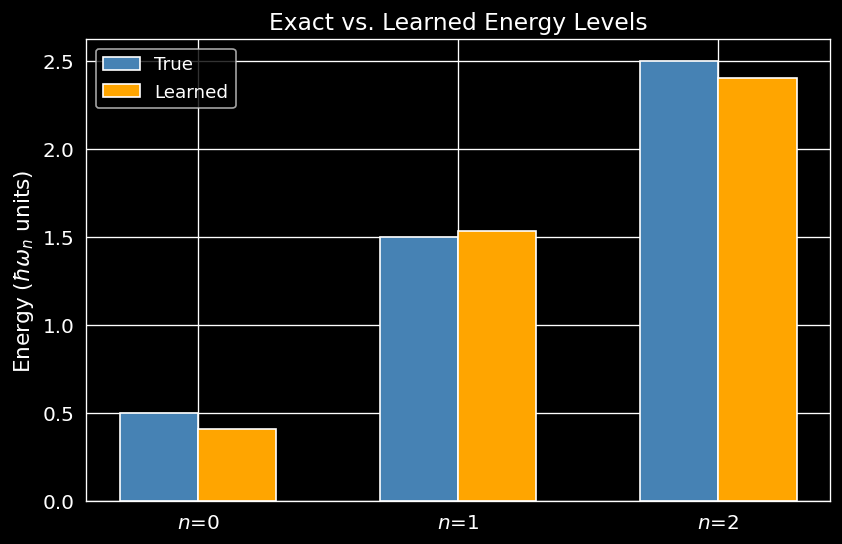

In [12]:
E_learned = model.E_theta().detach()

fig, ax = plt.subplots()
indices = torch.arange(len(E_true)).numpy()

ax.bar(indices - 0.15, E_true.numpy(), width=0.3, label="True", color="steelblue")
ax.bar(indices + 0.15, E_learned.numpy(), width=0.3, label="Learned", color="orange")

ax.set_xticks(indices)
ax.set_xticklabels([rf"$n$={i}" for i in indices])
ax.set_ylabel(rf"Energy ($\hbar \omega_n$ units)")
ax.set_title("Exact vs. Learned Energy Levels")
ax.legend()
plt.show()

## 5️⃣ Figure 5: Probability densities $|\psi_n(\theta, x)|^2$ vs. observations
- Plot
    -  $|\psi_n(x)|^2$
    - Observed $\rho_n(x)$
- Message
    - Data anchoring
    - Indirect supervision
    - Why phase remains unconstrained

In [13]:
# figure 5 code

## 6️⃣ Figure 6: Overlap matrix heatmap (POD diagnostic)
- Plot
    - Heatmap of $\langle \psi_m | \psi_n \rangle$
- Message
    - Near-orthogonality emerges (or not)
    - Coupling through shared $V(x)$
- ✨ This is very important for interpretability.

In [14]:
# Figure 6 code

## 7️⃣ Figure 7: POD singular values
- Plot
    - Singular values $\sigma_k$ vs. $k$ (log scale)
- Message
    - Effective dimensionality
    - Redundant modes
    - Capacity vs. constraint
- Failure mode
    - One dominant singular value -> collapse (❓)

In [15]:
# Figure 7 code

## 8️⃣ Figure 8: POD singular values and dominant modes 

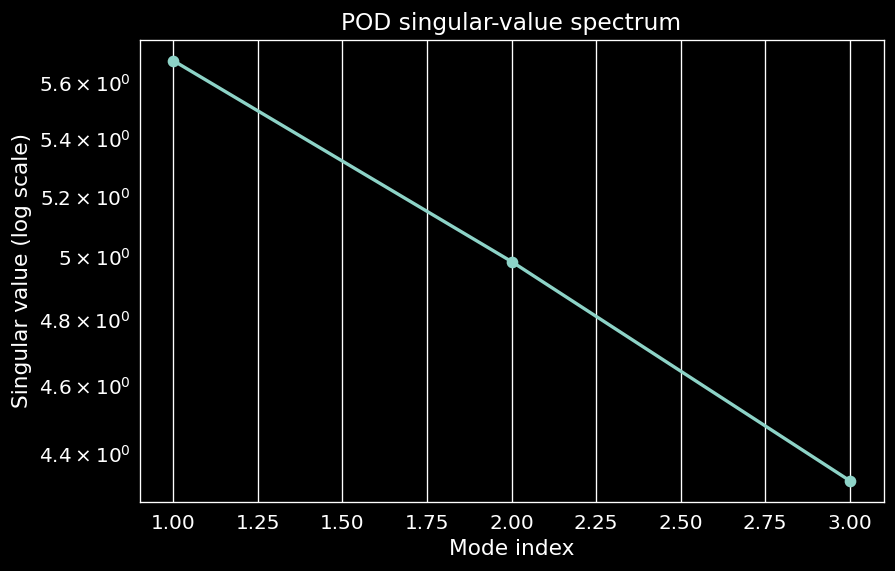

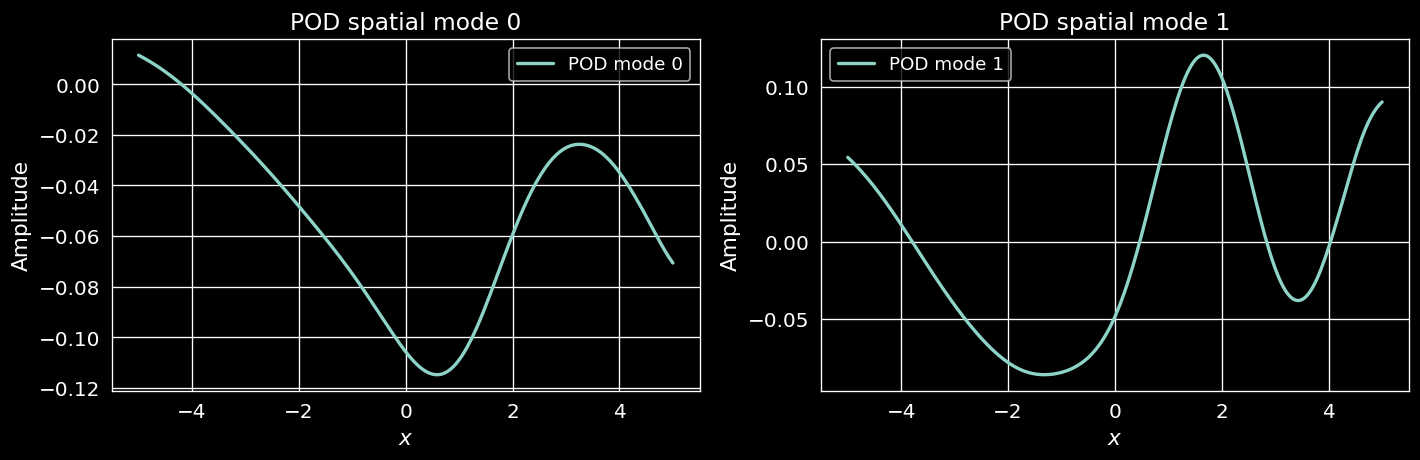

In [16]:
# Stack the learned wavefunctions column-wise to feed POD
psi_matrix = torch.stack(psi_learned, dim=1)    # shape (N, n_states)

U, S, Vh = pod_decomposition(psi_matrix)

# 8a - Singular values (energy content)
fig, ax = plt.subplots()
ax.semilogy(range(1, len(S)+1), S.detach().cpu().numpy(), "o-")
ax.set_xlabel("Mode index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("POD singular-value spectrum")
plt.show()

# 8b - First two spatial POD modes (they should resemble the true eigenmodes)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axs[k].plot(x.squeeze(), U[:, k].detach(), label=f"POD mode {k}")
    axs[k].set_xlabel(rf"$x$")
    axs[k].set_ylabel("Amplitude")
    axs[k].set_title(f"POD spatial mode {k}")
    axs[k].legend()
plt.tight_layout()
plt.show()

## 9️⃣ Figure 9: POD dominant modes vs. learned wavefunctions (optional if energy ordering is messy)
- Plot
    - Compare POD spatial modes to $\psi_n(\theta, x)$
- Message
    - Learned basis is not equivalent to ground truth physical eigenbasis
    - Still explains data

In [17]:
# Figure 9 code

## 🔟 Figure 10: Loss-weight bifurcation diagram
🥅 Generate a bifurcation diagram that gives us identifiability information.

### 📈 Plot
- $x$-axis: $\frac{\lambda_\text{phys}}{\lambda_\text{data}}$ (log scale)
- $y$-axis (multiple panels):
    - $|| V - V_\text{ref} ||_2$
    - smallest POD singular value
    - max off-diagonal overlap

### 🗝️ Key takeaway
> As physics dominace increases, identifiability goes through sharp transitions. Note that beyond a critical regime (❓ What is this?), the ${\psi_n}_\theta$ collapse into a low-dimensional subspace regardless of whether they satisfy the PDE.

- Makes interpretability axes concrete
- Shows where physics stops helping
- Distinguishes "stable but meaningless" from "informative"

### ✖️ Failure modes
- Flat $V(x)$ and low loss
- POD rank collapse
- Artificial orthogonality